In [1]:
# !pip install tensorflow pandas numpy scikit-learn gensim datasets transformers seqeval


In [2]:
# pip install keras==2.13.1
# pip install transformers==4.51.3
# pip install tensorflow==2.13
# !pip install livelossplot

In [30]:
# STEP 1: import library
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, TimeDistributed, Bidirectional
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from livelossplot.tf_keras import PlotLossesCallback

from tensorflow.keras.callbacks import TensorBoard
import datetime

from transformers import DistilBertTokenizerFast, TFDistilBertForTokenClassification
from transformers import DataCollatorForTokenClassification
from datasets import Dataset
import tensorflow as tf

from seqeval.metrics import classification_report
import matplotlib.pyplot as plt
from seqeval.metrics import classification_report

In [12]:

# Load dataset
df = pd.read_csv("ner_dataset.csv", encoding="latin1")
df = df.ffill()
df = df[["Sentence #", "Word", "Tag"]]

sampled_sentences = df["Sentence #"].dropna().unique()
sample_size = int(0.01 * len(sampled_sentences))  # CHANGE TO 1.0 *  TO USE 100% LATER

# sample_size = int(1.0 * len(sampled_sentences)) 

sampled_sentences = np.random.choice(sampled_sentences, sample_size, replace=False)
df = df[df["Sentence #"].isin(sampled_sentences)]

# Sentence grouping
class SentenceGetter:
    def __init__(self, data):
        self.grouped = data.groupby("Sentence #")[["Word", "Tag"]].apply(
            lambda s: list(zip(s["Word"].values, s["Tag"].values))
        )
        self.sentences = [s for s in self.grouped]

getter = SentenceGetter(df)
sentences = getter.sentences

# Create mappings
words = list(set(df["Word"].values))
words.append("ENDPAD")
tags = list(set(df["Tag"].values))

word2idx = {w: i + 1 for i, w in enumerate(words)}
tag2idx = {t: i for i, t in enumerate(tags)}
idx2tag = {i: w for w, i in tag2idx.items()}

max_len = 75
embedding_dim = 300

X = [[word2idx.get(w[0], 0) for w in s] for s in sentences]
X = pad_sequences(maxlen=max_len, sequences=X, padding="post", value=word2idx["ENDPAD"])
y = [[tag2idx[w[1]] for w in s] for s in sentences]
y = pad_sequences(maxlen=max_len, sequences=y, padding="post", value=tag2idx["O"])
y = [to_categorical(i, num_classes=len(tags)) for i in y]

# Train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=2/3, random_state=42)


In [13]:
# tags

In [14]:
# STEP 2: Define BiLSTM Model Builder

def build_bilstm_model(embedding_matrix=None, trainable=False):
    input = Input(shape=(max_len,))
    if embedding_matrix is not None:
        model = Embedding(input_dim=len(word2idx)+1, output_dim=embedding_dim,
                          weights=[embedding_matrix], input_length=max_len,
                          trainable=trainable)(input)
    else:
        model = Embedding(input_dim=len(word2idx)+1, output_dim=embedding_dim,
                          input_length=max_len)(input)
    model = Bidirectional(LSTM(units=50, return_sequences=True, recurrent_dropout=0.1))(model)
    out = TimeDistributed(Dense(len(tags), activation="softmax"))(model)
    model = Model(input, out)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model


In [15]:
early_stopping = EarlyStopping(monitor='val_accuracy',patience=1,verbose=0,mode='max',restore_best_weights=False)
callbacks = [PlotLossesCallback(),early_stopping]


In [16]:


log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

callbacks = [tensorboard_callback, early_stopping]


In [18]:
# STEP 3: Train Baseline BiLSTM (Random Embeddings)
baseline_model = build_bilstm_model()

baseline_history = baseline_model.fit(np.array(X_train), np.array(y_train),validation_data=(np.array(X_val), np.array(y_val)),
                   batch_size=32, epochs=5, verbose=1, callbacks = callbacks)


Epoch 1/2
11/11 [==============================] - 9s 287ms/step - loss: 2.2370 - accuracy: 0.7823 - val_loss: 1.2382 - val_accuracy: 0.9428
Epoch 2/2
11/11 [==============================] - 2s 214ms/step - loss: 0.5477 - accuracy: 0.9604 - val_loss: 0.3265 - val_accuracy: 0.9428


In [19]:
# terminal ;      tensorboard --logdir=logs/fit 
# http://localhost:6006/


In [20]:
# %tensorboard --logdir=logs/fit

In [22]:
baseline_model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 75)]              0         
                                                                 
 embedding_1 (Embedding)     (None, 75, 300)           941700    
                                                                 
 bidirectional_1 (Bidirecti  (None, 75, 100)           140400    
 onal)                                                           
                                                                 
 time_distributed_1 (TimeDi  (None, 75, 15)            1515      
 stributed)                                                      
                                                                 
Total params: 1083615 (4.13 MB)
Trainable params: 1083615 (4.13 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [23]:
i = np.random.randint(0, X_test.shape[0])
p = baseline_model.predict(np.array([X_test[i]]))
p = np.argmax(p, axis=-1)

y_true = np.argmax(np.array(y_test), axis=-1)[i]
print("{:15}{:5}\t {}\n".format("Word","True","Pred"))
print("-"*30)
for w,true,pred in zip(X_test[i], y_true, p[0]):
  print("{:15}{:5}\t{}".format(words[w-1], tags[true],tags[pred]))

1/1 [==============================] - 1s 668ms/step
Word           True 	 Pred

------------------------------
The            O    	O
islands        O    	O
were           O    	O
the            O    	O
only           O    	O
British        B-gpe	O
soil           O    	O
occupied       O    	O
by             O    	O
German         B-gpe	O
troops         O    	O
in             O    	O
World          O    	O
War            O    	O
II             B-eve	O
.              O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD         O    	O
ENDPAD        

In [24]:
# baseline_model.save("my_model")  # SSaved Model 


In [25]:
# STEP 4: Train BiLSTM with Word2Vec Embeddings
import gensim.downloader as api
w2v_model = api.load("word2vec-google-news-300")

embedding_matrix = np.zeros((len(word2idx) + 1, embedding_dim))
for word, i in word2idx.items():
    if word in w2v_model:
        embedding_matrix[i] = w2v_model[word]
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))


In [26]:
w2v_model_bilstm = build_bilstm_model(embedding_matrix=embedding_matrix, trainable=False)

w2v_history = w2v_model_bilstm.fit(np.array(X_train), np.array(y_train),validation_data=(np.array(X_val), np.array(y_val)),
                     batch_size=32, epochs=2, verbose=1)

Epoch 1/2
11/11 [==============================] - 9s 205ms/step - loss: 1.1290 - accuracy: 0.7988 - val_loss: 0.5496 - val_accuracy: 0.9419
Epoch 2/2
11/11 [==============================] - 1s 136ms/step - loss: 0.3763 - accuracy: 0.9603 - val_loss: 0.3206 - val_accuracy: 0.9428


In [27]:
# STEP 5: Train BERT Model using Hugging Face
# Using base_model DistilBERT

# Tokenizer and model
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-cased")
base_model = TFDistilBertForTokenClassification.from_pretrained("distilbert-base-cased", num_labels=len(tags))

# Prepare data
token_sentences = [[w[0] for w in s] for s in sentences]
ner_tags = [[tag2idx[w[1]] for w in s] for s in sentences]

dataset = Dataset.from_dict({"tokens": token_sentences, "ner_tags": ner_tags})

# Tokenization & alignment
def tokenize_and_align_labels(example):
    tokenized_inputs = tokenizer(example["tokens"], truncation=True, is_split_into_words=True,
                                 padding="max_length", max_length=max_len)
    labels = []
    for i, label in enumerate(example["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        label_ids = []
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            else:
                label_ids.append(label[word_id])
        labels.append(label_ids)
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# Apply tokenizer
encoded_dataset = dataset.map(tokenize_and_align_labels, batched=True)
encoded_dataset = encoded_dataset.train_test_split(test_size=0.2)

# Data collator
# data_collator = DataCollatorForTokenClassification(tokenizer)
data_collator = DataCollatorForTokenClassification(tokenizer, return_tensors="tf")

bert_train = encoded_dataset["train"].to_tf_dataset(
    columns=["attention_mask", "input_ids", "labels"],  # Include labels here
    shuffle=True,
    batch_size=8,
    collate_fn=data_collator,
)

bert_val = encoded_dataset["test"].to_tf_dataset(
    columns=["attention_mask", "input_ids", "labels"],  # Include labels here
    shuffle=False,
    batch_size=8,
    collate_fn=data_collator,
)


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForTokenClassification: ['vocab_transform.bias', 'vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertForTokenClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForTokenClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForTokenClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able t

Map:   0%|          | 0/479 [00:00<?, ? examples/s]

In [28]:
# Compile and train
# base_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5), loss=base_model.compute_loss)
base_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-3))

bert_history = base_model.fit(bert_train, validation_data=bert_val, epochs=2)

Epoch 1/2
48/48 [==============================] - 159s 3s/step - loss: 1.3055 - val_loss: 0.9924
Epoch 2/2
48/48 [==============================] - 172s 4s/step - loss: 0.9172 - val_loss: 0.9255


In [29]:
# STEP 6: Evaluate BiLSTM Models Using seqeval

def predict_BiLSTM_Word2Vectags(model, X_data, y_data):
    pred = model.predict(X_data)
    pred_labels = np.argmax(pred, axis=-1)
    true_labels = np.argmax(y_data, axis=-1)

    pred_tag = [[idx2tag[i] for i in row] for row in pred_labels]
    true_tag = [[idx2tag[i] for i in row] for row in true_labels]
    
    # Optionally strip padding (e.g., "ENDPAD") for cleaner results
    cleaned_true_tag = []
    cleaned_pred_tag = []
    for t_seq, p_seq, x_seq in zip(true_tag, pred_tag, X_data):
        temp_t = []
        temp_p = []
        for t, p, x in zip(t_seq, p_seq, x_seq):
            if x != word2idx["ENDPAD"]:  # skip padded tokens
                temp_t.append(t)
                temp_p.append(p)
        cleaned_true_tag.append(temp_t)
        cleaned_pred_tag.append(temp_p)

    return cleaned_true_tag, cleaned_pred_tag


true_b, pred_b = predict_BiLSTM_Word2Vectags(baseline_model, X_test, y_test)
true_w, pred_w = predict_BiLSTM_Word2Vectags(w2v_model_bilstm, X_test, y_test)

print("📊 Baseline BiLSTM Performance:")
print(classification_report(true_b, pred_b))

print("\n📊 Word2Vec BiLSTM Performance:")
print(classification_report(true_w, pred_w))



3/3 [==============================] - 1s 36ms/step
📊 Baseline BiLSTM Performance:


/home/a/anaconda3/envs/new_eda/lib/python3.10/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/a/anaconda3/envs/new_eda/lib/python3.10/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

         eve       0.00      0.00      0.00         1
         geo       0.00      0.00      0.00        79
         gpe       0.00      0.00      0.00        25
         org       0.00      0.00      0.00        27
         per       0.00      0.00      0.00        36
         tim       0.00      0.00      0.00        40

   micro avg       0.00      0.00      0.00       208
   macro avg       0.00      0.00      0.00       208
weighted avg       0.00      0.00      0.00       208


📊 Word2Vec BiLSTM Performance:
              precision    recall  f1-score   support

         eve       0.00      0.00      0.00         1
         geo       0.00      0.00      0.00        79
         gpe       0.00      0.00      0.00        25
         org       0.00      0.00      0.00        27
         per       0.00      0.00      0.00        36
         tim       0.00      0.00      0.00        40

   micro avg       0.00      0.00      0.00  

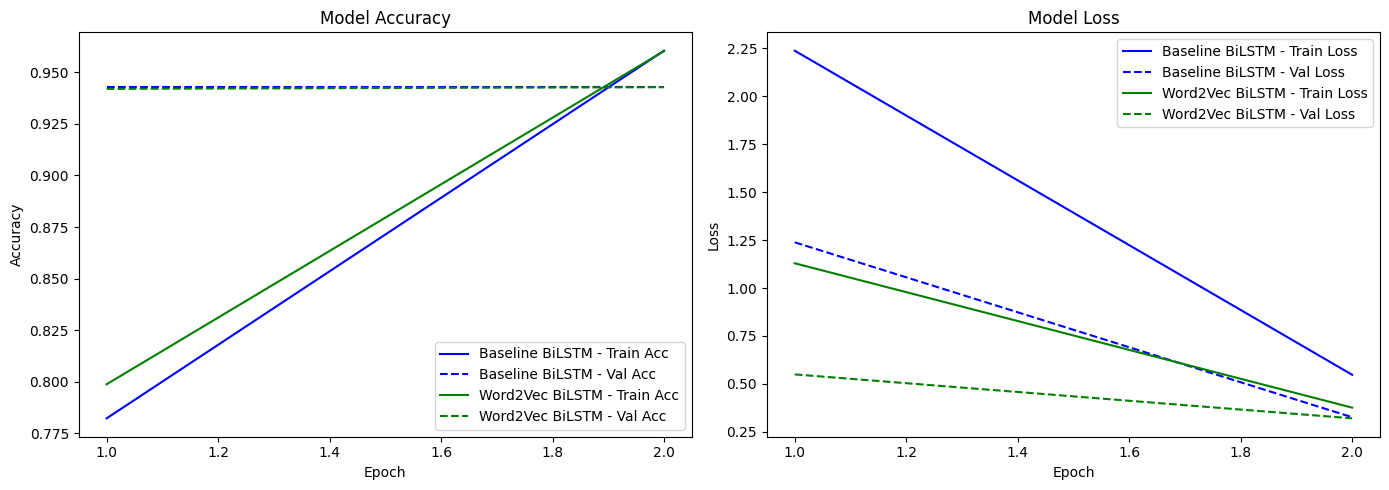

In [31]:

def plot_model_comparison(history1, history2, label1="Baseline BiLSTM", label2="Word2Vec BiLSTM"):
    epochs = range(1, len(history1.history['accuracy']) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history1.history['accuracy'], 'b-', label=f'{label1} - Train Acc')
    plt.plot(epochs, history1.history['val_accuracy'], 'b--', label=f'{label1} - Val Acc')
    plt.plot(epochs, history2.history['accuracy'], 'g-', label=f'{label2} - Train Acc')
    plt.plot(epochs, history2.history['val_accuracy'], 'g--', label=f'{label2} - Val Acc')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history1.history['loss'], 'b-', label=f'{label1} - Train Loss')
    plt.plot(epochs, history1.history['val_loss'], 'b--', label=f'{label1} - Val Loss')
    plt.plot(epochs, history2.history['loss'], 'g-', label=f'{label2} - Train Loss')
    plt.plot(epochs, history2.history['val_loss'], 'g--', label=f'{label2} - Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_model_comparison(baseline_history, w2v_history)


In [32]:
def predict_tags(model, tf_dataset):
    pred_logits = model.predict(tf_dataset).logits  # <-- Extract logits
    pred_labels = np.argmax(pred_logits, axis=-1)

    all_true_labels = []
    for batch in tf_dataset:
        all_true_labels.extend(batch['labels'].numpy())

    true_labels = np.array(all_true_labels)

    pred_tags = [[idx2tag[idx] for idx in row] for row in pred_labels]
    true_tags = [[idx2tag[idx] if idx != -100 else 'O' for idx in row] for row in true_labels]

    return true_tags, pred_tags

true_bert, pred_bert = predict_tags(base_model, bert_val)

print("\n📊 Transformer BERT Performance:")
print(classification_report(true_bert, pred_bert))


12/12 [==============================] - 11s 658ms/step

📊 Transformer BERT Performance:
              precision    recall  f1-score   support

         geo       0.00      0.00      0.00       118
         gpe       0.00      0.00      0.00        43
         nat       0.00      0.00      0.00         1
         org       0.00      0.00      0.00        64
         per       0.00      0.00      0.00        56
         tim       0.00      0.00      0.00        36

   micro avg       0.00      0.00      0.00       318
   macro avg       0.00      0.00      0.00       318
weighted avg       0.00      0.00      0.00       318



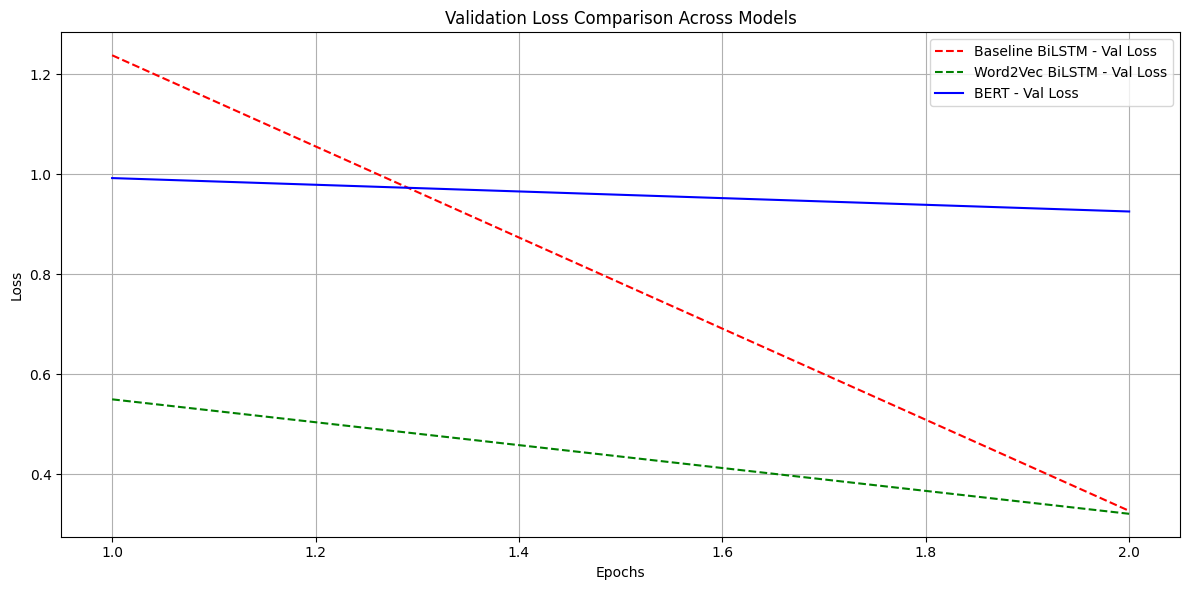

In [33]:
def plot_all_model_losses(baseline_hist, w2v_hist, bert_hist):
    epochs_bi = range(1, len(baseline_hist.history['loss']) + 1)
    epochs_bert = range(1, len(bert_hist.history['loss']) + 1)

    plt.figure(figsize=(12, 6))
    plt.plot(epochs_bi, baseline_hist.history['val_loss'], 'r--', label='Baseline BiLSTM - Val Loss')
    plt.plot(epochs_bi, w2v_hist.history['val_loss'], 'g--', label='Word2Vec BiLSTM - Val Loss')
    plt.plot(epochs_bert, bert_hist.history['val_loss'], 'b-', label='BERT - Val Loss')

    plt.title("Validation Loss Comparison Across Models")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call it
plot_all_model_losses(baseline_history, w2v_history, bert_history)


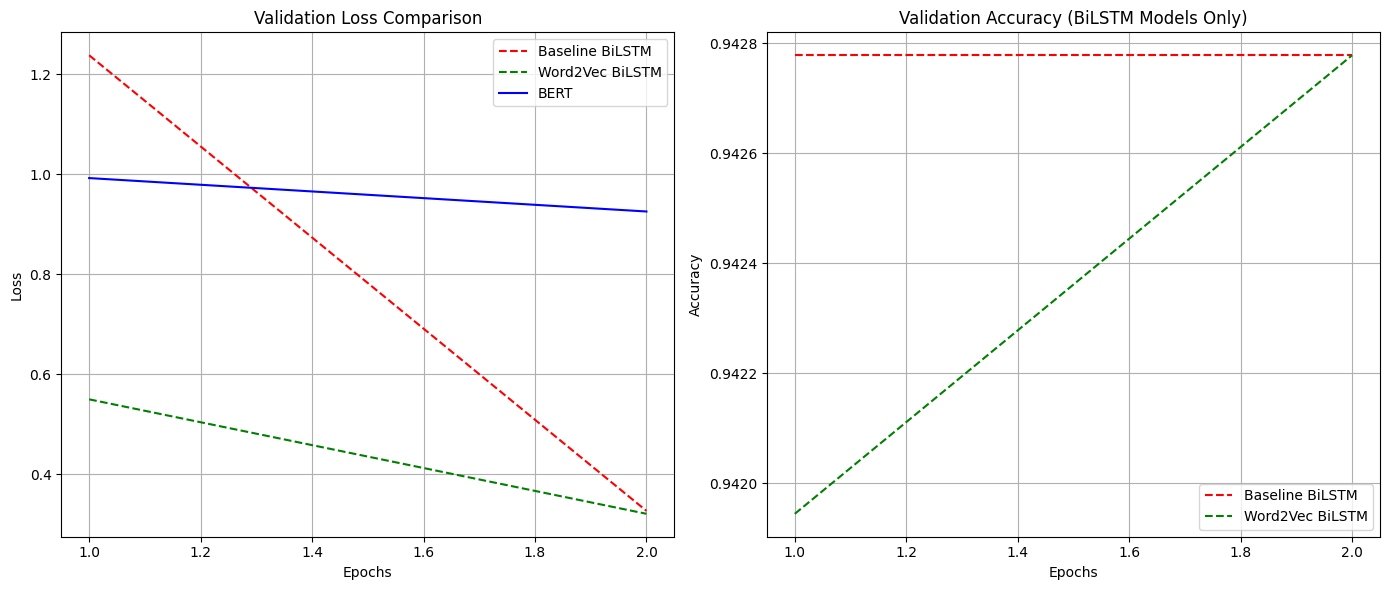

In [34]:
def plot_loss_accuracy_all(baseline_hist, w2v_hist, bert_hist):
    epochs_bi = range(1, len(baseline_hist.history['loss']) + 1)
    epochs_bert = range(1, len(bert_hist.history['loss']) + 1)

    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    # Loss plot
    axs[0].plot(epochs_bi, baseline_hist.history['val_loss'], 'r--', label='Baseline BiLSTM')
    axs[0].plot(epochs_bi, w2v_hist.history['val_loss'], 'g--', label='Word2Vec BiLSTM')
    axs[0].plot(epochs_bert, bert_hist.history['val_loss'], 'b-', label='BERT')
    axs[0].set_title("Validation Loss Comparison")
    axs[0].set_xlabel("Epochs")
    axs[0].set_ylabel("Loss")
    axs[0].legend()
    axs[0].grid(True)

    # Accuracy plot (BERT doesn't track accuracy by default)
    axs[1].plot(epochs_bi, baseline_hist.history['val_accuracy'], 'r--', label='Baseline BiLSTM')
    axs[1].plot(epochs_bi, w2v_hist.history['val_accuracy'], 'g--', label='Word2Vec BiLSTM')
    axs[1].set_title("Validation Accuracy (BiLSTM Models Only)")
    axs[1].set_xlabel("Epochs")
    axs[1].set_ylabel("Accuracy")
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

# Call the function
plot_loss_accuracy_all(baseline_history, w2v_history, bert_history)
